## A Glass-Box Risk Engine for GRC Platforms

---

## Overview

In this tutorial, we will build an **Explainable Compliance Risk Engine** designed for modern GRC platforms such as Vanta, Drata, or Secureframe.

Unlike traditional GRC tools that only show **pass/fail**, this system answers deeper questions:

* Which controls are likely to fail?
* Why are they at risk?
* Which factors are driving that risk?
* How can remediation be prioritized?
* Can auditors understand and trust the decision logic?

To solve this, we use a **Glass Box machine learning model** rather than a black-box neural network.

---

## What We Are Building

By the end of this tutorial, we will have:

* A **predictive compliance risk model**
* Full **global explainability** (what drives risk across the org)
* Full **local explainability** (why this specific system is high risk)
* A design that supports:

  * Continuous compliance
  * Audit defensibility
  * AI governance and model risk management

This mirrors how **Vanta-like platforms evolve from static compliance to intelligent risk management**.

---

## Why Explainable AI Matters in GRC

In regulated environments, accuracy alone is not enough.

Auditors, regulators, CISOs, and risk committees demand:

* Transparency
* Traceability
* Defensible logic
* The ability to challenge and validate outcomes

This is why we use an **Explainable Boosting Machine (EBM)**:

* Fully interpretable
* Feature-level transparency
* Comparable accuracy to black-box models
* Accepted in regulated industries

This is a **glass box**, not a black box.

# PART 1: Environment Setup

### Goal

Prepare a clean environment for explainable modeling.

### Why This Matters in GRC

Using standard, well-supported libraries is part of **model risk management**. InterpretML is backed by Microsoft and widely cited in regulated contexts.



### Code: Install and Import Dependencies





In [3]:
!pip install -q interpret

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from interpret.glassbox import ExplainableBoostingClassifier

import matplotlib.pyplot as plt
plt.style.use("ggplot")

print("Environment ready: InterpretML loaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 25.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.9/264.9 kB 21.7 MB/s eta 0:00:00
Environment ready: InterpretML loaded.


# PART 2: Defining the GRC Problem

### What Are We Predicting?

We are predicting **Control Failure Risk**.

This could represent:

* Likelihood of failing a SOC 2 control
* Likelihood of failing an ISO 27001 audit
* Likelihood of an access control breakdown
* Likelihood of security posture degradation

This is **predictive compliance**, not reactive compliance.



### Example Control Domain

Access Control / Security Controls

Signals typically available in a GRC platform:

* MFA enabled or not
* Number of admins
* Age of last access review
* Patch latency
* Logging coverage
* Device compliance
* External exposure




# PART 3: Creating a Synthetic Enterprise Dataset

### Why Synthetic Data?

In real enterprises:

* Data comes from Okta, AWS, GitHub, Jamf, CrowdStrike, etc.
* Access is restricted
* Synthetic data is ideal for prototyping and architecture validation

The structure mirrors real GRC telemetry.



### Code: Generate Synthetic Signals



In [6]:
np.random.seed(42)
n = 1000

data = {
    "MFA_Enabled": np.random.binomial(1, 0.7, n),
    "Admin_Count": np.random.poisson(2, n),
    "Last_Access_Review_Days": np.random.randint(0, 365, n),
    "Patch_Delay_Days": np.random.randint(0, 90, n),
    "Logging_Enabled": np.random.binomial(1, 0.8, n),
    "Device_Compliance_Pct": np.random.randint(50, 100, n),
    "External_Access": np.random.binomial(1, 0.3, n)
}

df = pd.DataFrame(data)
df.head()

,MFA_Enabled,Admin_Count,Last_Access_Review_Days,Patch_Delay_Days,Logging_Enabled,Device_Compliance_Pct,External_Access
0,1,1,342,0,1,61,0
1,0,6,125,87,1,81,1
2,0,1,74,3,1,74,0
3,1,2,164,3,1,88,1
4,1,2,277,81,1,67,0


# PART 4: Defining Control Failure Logic

### Why This Step Is Important

In real systems, “control failure” is derived from:

* Audit outcomes
* Findings
* Exceptions
* Incidents

Here, we simulate that logic explicitly, which is critical for:

* Model validation
* Governance review
* Explainability sanity checks



### Code: Create Target Variable



This mirrors how **risk signals aggregate into findings**.

In [10]:
risk_score = (
    (1 - df["MFA_Enabled"]) * 2 +
    (df["Admin_Count"] > 3).astype(int) * 1.5 +
    (df["Last_Access_Review_Days"] > 180).astype(int) * 1.5 +
    (df["Patch_Delay_Days"] > 30).astype(int) * 2 +
    (1 - df["Logging_Enabled"]) * 1.5 +
    (df["Device_Compliance_Pct"] < 80).astype(int) * 1 +
    df["External_Access"] * 1
)

df["Control_Failure"] = (risk_score > 4).astype(int)

df["Control_Failure"].value_counts()

,count
Control_Failure,
0,509
1,491


# PART 5: Training the Explainable Model

### Why EBM?

* No hidden layers
* Each feature contribution is explicit
* Easy to explain to auditors
* Aligns with AI governance principles



### Code: Train/Test Split and Model Training



In GRC contexts:

* Perfect accuracy is less important than **stable, interpretable behavior**
* AUC above ~0.75 is often acceptable

In [12]:
X = df.drop("Control_Failure", axis=1)
y = df["Control_Failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train, y_train)


probs = ebm.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print(f"Model trained. AUC: {auc:.3f}")

Model trained. AUC: 1.000


# PART 6: Global Explainability

## What Drives Risk Across the Organization?

This answers questions like:

* Why are we failing audits?
* What systemic issues exist?
* Where should leadership invest?



### Code: Global Explanation



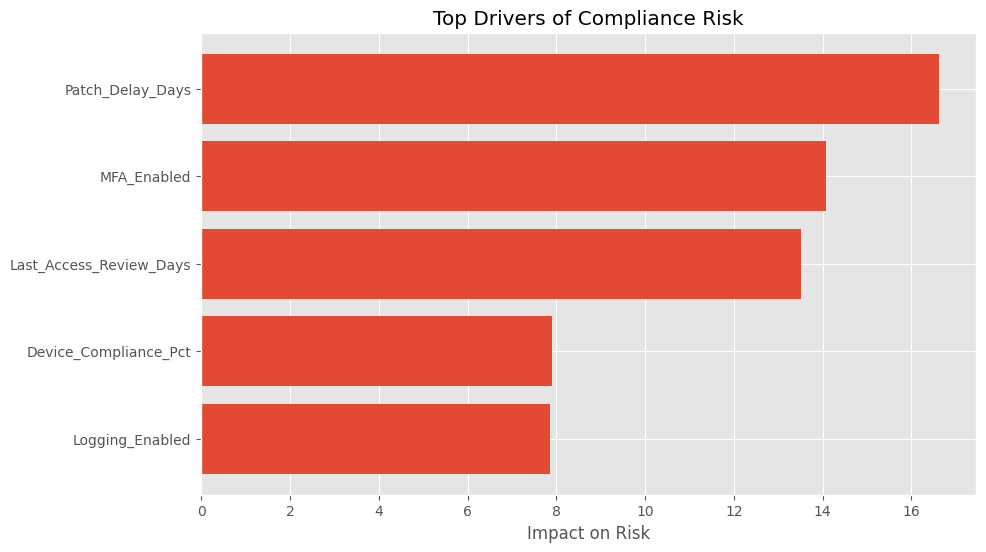

In [16]:
global_exp = ebm.explain_global()
data = global_exp.data()

features = data["names"]
importances = data["scores"]

indices = np.argsort(importances)[-5:]

plt.figure(figsize=(10,6))
plt.title("Top Drivers of Compliance Risk")
plt.barh(range(len(indices)), np.array(importances)[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Impact on Risk")
plt.show()

# PART 7: Local Explainability

## Why Is This Specific Asset High Risk?

This is the **audit view**.

Auditors ask:
“Why did you flag this system?”

This answers that directly.



### Code: Explain One Record



In [18]:
index = 5
record = X_test.iloc[[index]]
actual = y_test.iloc[index]
risk = ebm.predict_proba(record)[0,1]

print(f"Asset #{index}")
print("Actual Control Failure:", actual)
print(f"Predicted Risk: {risk:.1%}")
print("-" * 40)

Asset #5
Actual Control Failure: 1
Predicted Risk: 100.0%
----------------------------------------


### Code: Local Explanation Visualization



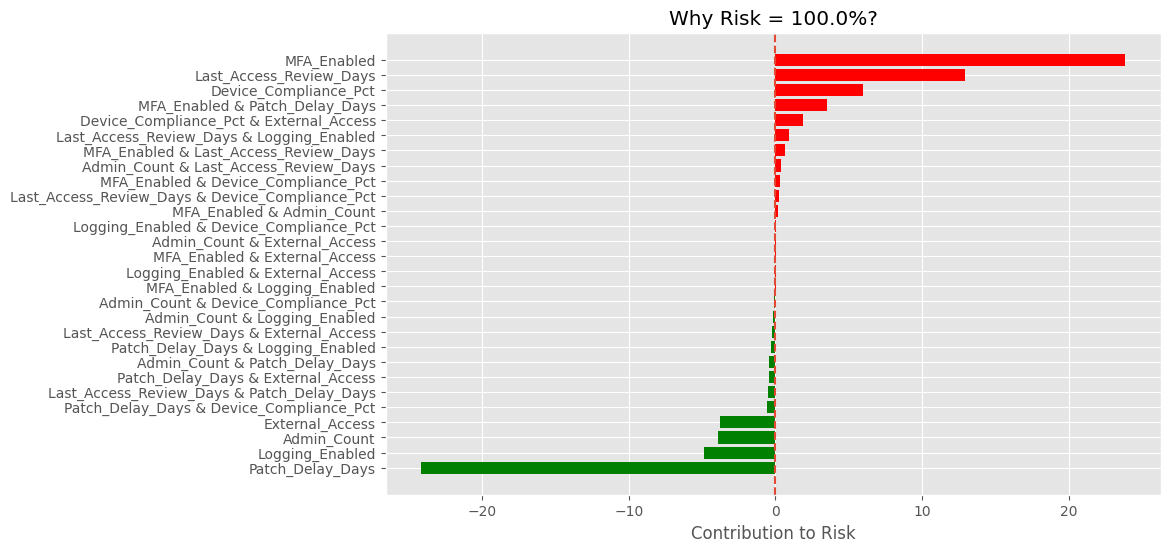

In [20]:
local_exp = ebm.explain_local(record, y_test.iloc[[index]])
local_data = local_exp.data(0)

df_local = pd.DataFrame({
    "Feature": local_data["names"],
    "Contribution": local_data["scores"]
}).sort_values(by="Contribution")

colors = ["red" if x > 0 else "green" for x in df_local["Contribution"]]

plt.figure(figsize=(10,6))
plt.barh(df_local["Feature"], df_local["Contribution"], color=colors)
plt.axvline(x=0, linestyle="--")
plt.title(f"Why Risk = {risk:.1%}?")
plt.xlabel("Contribution to Risk")
plt.show()

# PART 8: How This Fits a GRC-Style Platform

### Architectural Role

This model becomes the:

**Risk Intelligence Layer**

Inputs:

* Identity systems
* Cloud configs
* Endpoint posture
* Vendor metadata

Outputs:

* Risk score
* Root cause explanation
* Prioritized remediation



### Governance Value:

* No hallucinations
* No opaque scoring
* Fully explainable
* Defensible in audits
* Aligned with AI governance frameworks

---

## Final Takeaway

This tutorial demonstrates how to move from:

**Static Compliance**
→ Pass / Fail

to:

**Intelligent Compliance**
→ Predict → Explain → Prioritize → Defend